In [3]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from datetime import datetime

PROJECT_ROOT = Path("..").resolve()
DB_PATH      = PROJECT_ROOT / "nhs_ae.duckdb"
con          = duckdb.connect(str(DB_PATH), read_only=True)

print("Connected to database")

Connected to database


In [4]:
# Latest successful refresh
latest_refresh = con.execute("""
    SELECT
        MAX(completed_at)   AS last_updated,
        COUNT(*)            AS total_loads,
        SUM(rows_loaded)    AS total_rows_loaded
    FROM audit.refresh_log
    WHERE status = 'success'
""").fetchone()

open_issues = con.execute("""
    SELECT COUNT(*) FROM audit.quality_issues
    WHERE severity = 'ERROR'
""").fetchone()[0]

print("=" * 55)
print("  NHS A&E PIPELINE — DASHBOARD")
print("=" * 55)
print(f"  Last updated : {latest_refresh[0]}")
print(f"  Total loads  : {latest_refresh[1]}")
print(f"  Rows loaded  : {latest_refresh[2]}")
print(f"  Open errors  : {open_issues}")
print("=" * 55)

  NHS A&E PIPELINE — DASHBOARD
  Last updated : 2026-09-20 14:56:57.261967
  Total loads  : 15
  Rows loaded  : 2976
  Open errors  : 0


In [5]:
monthly = con.execute("""
    SELECT
        strftime(period, '%b %Y')               AS month,
        SUM(type1_attendances)                  AS type1_attendances,
        SUM(total_attendances)                  AS total_attendances,
        ROUND(
            100.0 * SUM(within_4h_type1)
            / NULLIF(SUM(type1_attendances), 0)
        , 1)                                    AS four_hour_pct,
        SUM(wait_12plus_dta)                    AS waits_12plus
    FROM reporting.ae_monthly
    GROUP BY period
    ORDER BY period
""").df()

print("Monthly national summary:")
print(monthly.to_string(index=False))

Monthly national summary:
   month  type1_attendances  total_attendances  four_hour_pct  waits_12plus
Nov 2025          1420033.0          2263562.0           60.1       50648.0
Dec 2025          1407641.0          2239924.0           59.3       50789.0
Jan 2026          1405035.0          2235696.0           57.0       71517.0
Feb 2026          1271830.0          2043572.0           59.1       54649.0
Mar 2026          1451010.0          2351347.0           63.9       46665.0


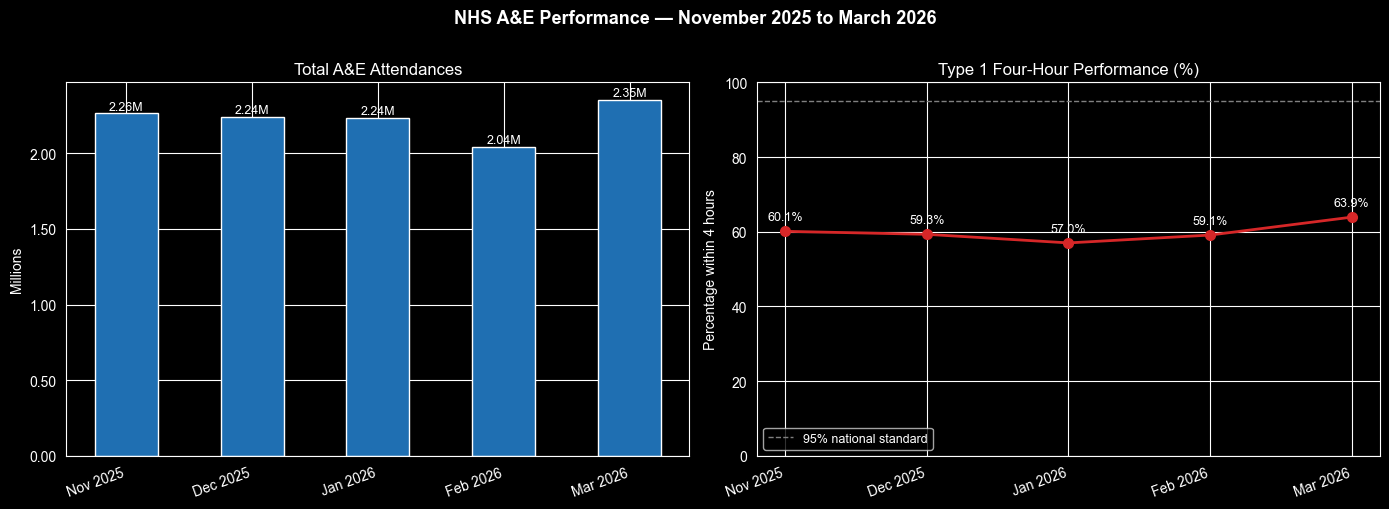

Charts saved to docs/dashboard_charts.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("NHS A&E Performance — November 2025 to March 2026",
             fontsize=13, fontweight="bold", y=1.01)

months     = monthly["month"].tolist()
x          = range(len(months))
bar_colour = "#1f6fb2"
line_col   = "#d62728"

# Chart 1: Total attendances by month
ax1 = axes[0]
bars = ax1.bar(x, monthly["total_attendances"] / 1_000_000,
               color=bar_colour, width=0.5)
ax1.set_title("Total A&E Attendances")
ax1.set_ylabel("Millions")
ax1.set_xticks(x)
ax1.set_xticklabels(months, rotation=20, ha="right")
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
for bar, val in zip(bars, monthly["total_attendances"]):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f"{val/1_000_000:.2f}M",
             ha="center", va="bottom", fontsize=9)

# Chart 2: Type 1 four-hour performance
ax2 = axes[1]
ax2.plot(x, monthly["four_hour_pct"], color=line_col,
         marker="o", linewidth=2, markersize=7)
ax2.axhline(y=95, color="grey", linestyle="--",
            linewidth=1, label="95% national standard")
ax2.set_title("Type 1 Four-Hour Performance (%)")
ax2.set_ylabel("Percentage within 4 hours")
ax2.set_xticks(x)
ax2.set_xticklabels(months, rotation=20, ha="right")
ax2.set_ylim(0, 100)
ax2.legend(fontsize=9)
for i, val in enumerate(monthly["four_hour_pct"]):
    ax2.annotate(f"{val}%", (i, val),
                 textcoords="offset points",
                 xytext=(0, 8), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "dashboard_charts.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Charts saved to docs/dashboard_charts.png")

In [7]:
latest_period = con.execute(
    "SELECT MAX(period) FROM reporting.ae_monthly"
).fetchone()[0]

providers = con.execute("""
    SELECT
        org_code,
        org_name,
        type1_attendances,
        four_hour_pct_type1,
        wait_12plus_dta
    FROM reporting.ae_monthly
    WHERE period = ?
      AND type1_attendances > 0
    ORDER BY four_hour_pct_type1 ASC
""", [latest_period]).df()

print(f"Provider performance — {latest_period}")
print(f"\n10 lowest Type 1 performers:")
print(providers.head(10).to_string(index=False))
print(f"\n5 highest Type 1 performers:")
print(providers.tail(5).to_string(index=False))

Provider performance — 2026-03-01

10 lowest Type 1 performers:
org_code                                                 org_name  type1_attendances  four_hour_pct_type1  wait_12plus_dta
     RK9                  UNIVERSITY HOSPITALS PLYMOUTH NHS TRUST               9053                 37.4              352
     RX1                NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST              13228                 44.6             1200
     RXW            THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST              11446                 45.1             1173
     RJE         UNIVERSITY HOSPITALS OF NORTH MIDLANDS NHS TRUST              15324                 46.6              820
     RBT              MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST               7509                 47.4              665
     RN3             GREAT WESTERN HOSPITALS NHS FOUNDATION TRUST               6241                 47.9              436
     RBL WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDATION TRUST          

In [8]:
issues = con.execute("""
    SELECT
        qi.detected_at,
        rl.source_file,
        qi.check_name,
        qi.severity,
        qi.description,
        qi.affected_rows
    FROM audit.quality_issues qi
    LEFT JOIN audit.refresh_log rl ON qi.load_id = rl.load_id
    ORDER BY qi.detected_at DESC
    LIMIT 20
""").df()

if len(issues) == 0:
    print("✅ No quality issues recorded")
else:
    print(f"Quality issues log ({len(issues)} entries):")
    print(issues.to_string(index=False))

✅ No quality issues recorded


In [10]:
# Cell 7 — Dashboard verification (fixed)

print("=== Dashboard verification ===\n")

# Figure 1
dash_total = monthly[monthly["month"] == monthly["month"].iloc[-1]]["total_attendances"].values[0]
sql_total = con.execute("""
    SELECT SUM(total_attendances)
    FROM reporting.ae_monthly
    WHERE period = (SELECT MAX(period) FROM reporting.ae_monthly)
""").fetchone()[0]

print(f"Latest month total attendances:")
print(f"  Dashboard value : {dash_total:,.0f}")
print(f"  SQL query       : {sql_total:,.0f}")
print(f"  Match: {'✅ YES' if dash_total == sql_total else '❌ NO'}\n")

# Figure 2
dash_pct = monthly[monthly["month"] == "Nov 2025"]["four_hour_pct"].values[0]
sql_pct = con.execute("""
    SELECT ROUND(
        100.0 * SUM(within_4h_type1) / NULLIF(SUM(type1_attendances), 0)
    , 1)
    FROM reporting.ae_monthly
    WHERE period = '2025-11-01'
""").fetchone()[0]

print(f"November 2025 four-hour performance:")
print(f"  Dashboard value : {dash_pct}%")
print(f"  SQL query       : {sql_pct}%")
print(f"  Match: {'✅ YES' if dash_pct == sql_pct else '❌ NO'}\n")

# Trigger quality check — close read-only first, then open writable
print("Triggering a quality check deliberately...")
con.close()  # close read-only connection

con_write = duckdb.connect(str(DB_PATH))  # open writable
con_write.execute("""
    INSERT INTO reporting.ae_monthly
        (period, org_code, org_name, type1_attendances,
         four_hour_pct_type1, source_file, loaded_at)
    VALUES ('2026-03-01', NULL, 'TEST', -1, 150.0, 'TEST', NOW())
""")
con_write.execute("""
    INSERT INTO audit.quality_issues
        (issue_id, load_id, check_name, severity,
         description, affected_rows, detected_at)
    VALUES (9999, 9999, 'MISSING_ORG_CODE', 'ERROR',
            'TEST: 1 row has missing org_code', 1, NOW())
""")

# Check it appears
issues_after = con_write.execute("""
    SELECT check_name, severity, description
    FROM audit.quality_issues
    ORDER BY detected_at DESC
    LIMIT 3
""").df()
print("Quality issues table after deliberate trigger:")
print(issues_after.to_string(index=False))

# Clean up
con_write.execute("DELETE FROM reporting.ae_monthly WHERE source_file = 'TEST'")
con_write.execute("DELETE FROM audit.quality_issues WHERE issue_id = 9999")
con_write.close()
print("\n✅ Test data removed")

# Reopen read-only for rest of session
con = duckdb.connect(str(DB_PATH), read_only=True)
print("✅ Read-only connection restored")

=== Dashboard verification ===

Latest month total attendances:
  Dashboard value : 2,351,347
  SQL query       : 2,351,347
  Match: ✅ YES

November 2025 four-hour performance:
  Dashboard value : 60.1%
  SQL query       : 60.1%
  Match: ✅ YES

Triggering a quality check deliberately...
Quality issues table after deliberate trigger:
      check_name severity                      description
MISSING_ORG_CODE    ERROR TEST: 1 row has missing org_code

✅ Test data removed
✅ Read-only connection restored


In [11]:
con.close()
print("Connection closed")

Connection closed
